# Dilemme choc / vibration
## Système masse-ressort-amortisseur à 1 degré de liberté

### Modèle physique

On note $z(t) = x_m - x_s$ le **déplacement relatif** de la masse par rapport au sol.
C'est la déformation de l'emballage : la grandeur pertinente pour évaluer le risque de débattement.

Le principe fondamental de la dynamique en coordonnée relative donne :

$$\ddot{z} + 2\zeta\omega_0\dot{z} + \omega_0^2 z = -a_{\text{choc}}(t)$$

avec $\omega_0 = 2\pi f_0 = \sqrt{k/m}$ et $\zeta = c\,/\,(2\sqrt{km})$.

Le **signe négatif** traduit l'inertie : le sol accélère vers le haut, la masse tend à rester immobile.

### Accélération transmise à la masse

En substituant $\ddot{z}$ depuis l'équation différentielle dans $\ddot{x}_m = a_{\text{choc}} + \ddot{z}$ :

$$\ddot{x}_m = -\omega_0^2\,z - 2\zeta\omega_0\dot{z} = -\frac{kz + c\dot{z}}{m}$$

L'accélération transmise est la **force de rappel de l'emballage divisée par la masse**.
Elle est proportionnelle à $z$ (pour $\zeta$ faible), ce qui lie directement les deux graphiques.

### Stratégie de simulation (deux phases exactes)

1. **Phase forcée** ($0 \leq t \leq T_{\text{choc}}$) : intégration de l'équation différentielle avec $a_{\text{choc}}(t)\neq 0$.
   On récupère les conditions exactes $(z_0,\dot{z}_0)$ à $t = T_{\text{choc}}$.
2. **Oscillation libre** ($t > T_{\text{choc}}$) : intégration sans forçage depuis $(z_0,\dot{z}_0)$.
   Le temps est remis à zéro : $t' = t - T_{\text{choc}}$.

Ce n'est pas une approximation, c'est la solution exacte découpée en deux régimes.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({
    'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# --- Paramètres physiques ---
m      = 1000.0       # masse de la palette chargée (kg)
g_std  = 9.81         # accélération de la pesanteur (m/s²)
A_choc = 10 * g_std   # amplitude du choc : 10 gₙ en m/s²
T_choc = 11e-3        # durée du choc : 11 ms (profil DIN EN 60068-2-27)

def a_choc(t):
    # Profil d'accélération du sol : demi-sinusoïde sur [0, T_choc], nul ailleurs.
    # L'expression conditionnelle (ternaire Python) garantit la causalité :
    # le sol est au repos avant t=0 et après t=T_choc.
    # La demi-sinusoïde est le profil normatif de choc le plus courant :
    return A_choc * np.sin(np.pi * t / T_choc) if 0 <= t <= T_choc else 0.0

# --- Trois configurations : souple / médium / rigide ---
# Même amortissement réduit ζ = 0,10 pour les trois (propriété du matériau carton,
# indépendante de la géométrie de cannelure).
configs = [
    {'label': 'Souple  ($f_0=2$ Hz)',  'f0': 2,  'zeta': 0.10, 'color': '#E05A2B', 'ls': '-'},
    {'label': 'Médium  ($f_0=5$ Hz)',  'f0': 5,  'zeta': 0.10, 'color': '#2B7BE0', 'ls': '--'},
    {'label': 'Rigide  ($f_0=10$ Hz)', 'f0': 10, 'zeta': 0.10, 'color': '#2BA85A', 'ls': ':'},
]

def transmissibilite_dB(f, f0, zeta):
    # Transmissibilité en amplitude pour une excitation par la base, régime permanent.
    # r = f/f0 : rapport de fréquences réduit (adimensionné).
    # Formule : T = sqrt((1+(2*zeta*r)^2) / ((1-r^2)^2+(2*zeta*r)^2))
    # Différence avec la FRF classique : le numérateur contient (1+(2*zeta*r)^2) au lieu de 1,
    # car la base transmet à la fois via le ressort ET via l'amortisseur.
    # Retourne la valeur en dB : 20*log10(T) pour le diagramme de Bode.
    r = f / f0
    T = np.sqrt((1+(2*zeta*r)**2)/((1-r**2)**2+(2*zeta*r)**2))
    return 20*np.log10(T)

def simuler(f0, zeta, t_libre=0.6):
    # Résolution numérique de l'équation différentielle en coordonnée relative z = x_masse - x_sol.
    # Equation du mouvement : z'' + 2*zeta*omega0*z' + omega0^2*z = -a_choc(t)
    # Découpée en deux phases exactes (pas une approximation).
    omega0 = 2*np.pi*f0

    # Phase 1 : choc forcé — le sol accélère, forçage actif sur [0, T_choc].
    # Etat : y = [z, z']. Retour : [z', z''] avec z'' = -2*zeta*omega0*z' - omega0^2*z - a_choc(t).
    def eq_forcee(t, y):
        z, dz = y
        return [dz, -2*zeta*omega0*dz - omega0**2*z - a_choc(t)]
    sol1 = solve_ivp(eq_forcee, [0, T_choc], [0.0, 0.0],
                     dense_output=True, rtol=1e-10, atol=1e-12)

    # Conditions de raccordement : valeurs exactes à la fin du choc.
    z0, dz0 = sol1.y[0,-1], sol1.y[1,-1]

    # Phase 2 : oscillation libre — sol immobile, système oscille depuis (z0, dz0).
    def eq_libre(t, y):
        z, dz = y
        return [dz, -2*zeta*omega0*dz - omega0**2*z]
    sol2 = solve_ivp(eq_libre, [0, t_libre], [z0, dz0],
                     t_eval=np.linspace(0, t_libre, 5000), rtol=1e-10, atol=1e-12)
    z, dz = sol2.y[0], sol2.y[1]

    # Accélération absolue de la masse (en g) en phase libre.
    # PFD sur la masse : m*x_m'' = -k*z - c*z' = -m*omega0^2*z - m*2*zeta*omega0*z'
    # Donc x_m'' = -omega0^2*z - 2*zeta*omega0*z' (sol immobile => x_sol'' = 0).
    a_abs_g = (-omega0**2*z - 2*zeta*omega0*dz) / g_std
    return sol2.t*1000, z*1000, a_abs_g   # temps en ms, déplacement en mm, accélération en g

# Tableau de fréquences pour le Bode : espacement logarithmique.
# np.logspace(a, b, N) génère N points entre 10^a et 10^b.
# 10^(-0.3) ≈ 0.5 Hz  ;  10^log10(150) = 150 Hz  ;  2000 points → courbe lisse.
f_bode = np.logspace(-0.3, np.log10(150), 2000)
print('Fonctions définies.')

Fonctions définies.


## 1. Diagramme de Bode — transmissibilité

La zone grisée représente la bande de sollicitation mesurée en transport (1–120 Hz).

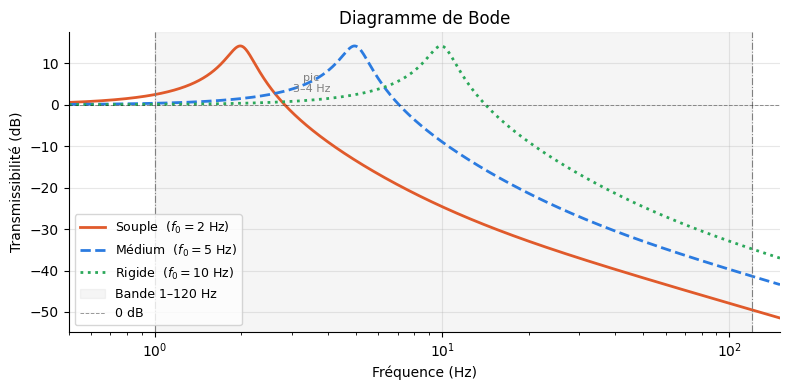

In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    ax.semilogx(f_bode, transmissibilite_dB(f_bode, cfg['f0'], cfg['zeta']),
                color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])
ax.axvspan(1, 120, alpha=0.08, color='gray', label='Bande 1–120 Hz')
ax.axvline(1,  color='gray', lw=0.8, ls='-.')
ax.axvline(120,color='gray', lw=0.8, ls='-.')
ax.axhline(0,  color='black', lw=0.7, ls='--', alpha=0.4, label='0 dB')
ax.annotate('pic\n3–4 Hz', xy=(3.5, 3), fontsize=8, color='gray', ha='center')
ax.set_xlabel('Fréquence (Hz)'); ax.set_ylabel('Transmissibilité (dB)')
ax.set_title('Diagramme de Bode'); ax.set_xlim(0.5, 150); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 2. Déplacement relatif après le choc

$z(t')$ est la déformation de l'emballage pendant l'oscillation libre ($t' = 0$ = fin du choc).
Le pic représente le **débattement maximal**.

f0 =  2.0 Hz  →  z_max = +47.1 mm
f0 =  5.0 Hz  →  z_max = +18.8 mm
f0 = 10.0 Hz  →  z_max = +9.3 mm


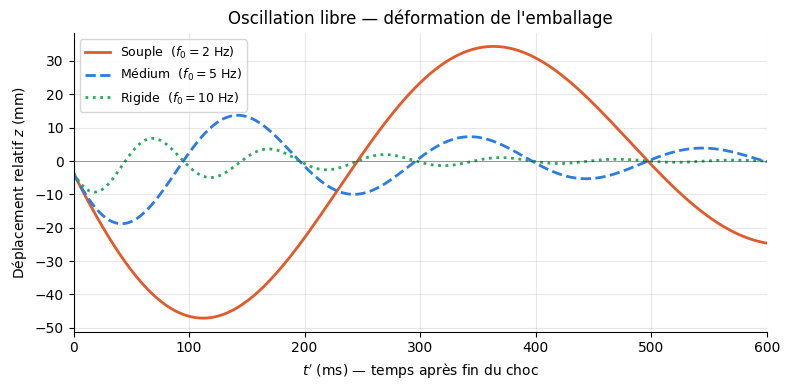

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    t_ms, z_mm, _ = simuler(cfg['f0'], cfg['zeta'])
    ax.plot(t_ms, z_mm, color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])
    print(f"f0 = {cfg['f0']:4.1f} Hz  →  z_max = {np.max(np.abs(z_mm)):+.1f} mm")
ax.axhline(0, color='black', lw=0.6, alpha=0.4)
ax.set_xlabel("$t'$ (ms) — temps après fin du choc")
ax.set_ylabel('Déplacement relatif $z$ (mm)')
ax.set_title('Oscillation libre — déformation de l\'emballage')
ax.set_xlim(0, 600); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 3. Accélération absolue transmise à la masse

$$\ddot{x}_m = -\omega_0^2\,z - 2\zeta\omega_0\dot{z}$$

Vérification : pour le souple ($f_0=2$ Hz), $z_{\max}\approx 40$ mm, $\omega_0^2=(2\pi\times 2)^2\approx 158$ rad²/s²,
donc $|\ddot{x}_m|_{\max} \approx 158\times 0{,}040\,/\,9{,}81 \approx 0{,}6$ g — lisible sur le graphique.

Souple  ($f_0=2$ Hz)                 a_max = +0.77 g
Médium  ($f_0=5$ Hz)                 a_max = +1.93 g
Rigide  ($f_0=10$ Hz)                a_max = +3.83 g


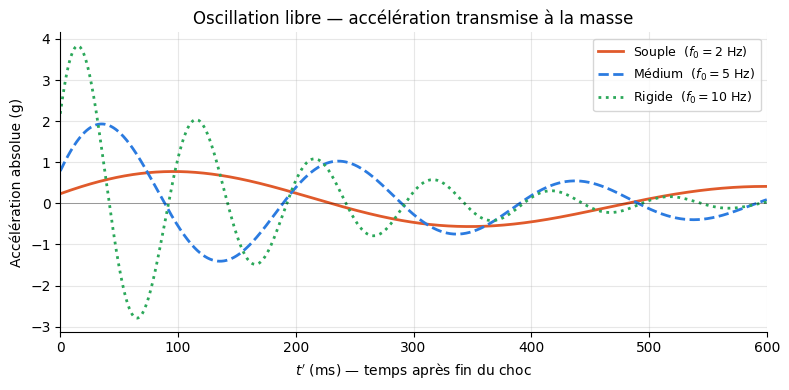

In [51]:
fig, ax = plt.subplots(figsize=(8, 4))
for cfg in configs:
    t_ms, _, a_g = simuler(cfg['f0'], cfg['zeta'])
    ax.plot(t_ms, a_g, color=cfg['color'], ls=cfg['ls'], lw=2, label=cfg['label'])
    print(f"{cfg['label']:35s}  a_max = {np.max(np.abs(a_g)):+.2f} g")
ax.axhline(0, color='black', lw=0.6, alpha=0.4)
ax.set_xlabel("$t'$ (ms) — temps après fin du choc")
ax.set_ylabel('Accélération absolue (g)')
ax.set_title('Oscillation libre — accélération transmise à la masse')
ax.set_xlim(0, 600); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Exploration interactive — $f_0$ et $\zeta$

Les courbes de référence restent en gris. L'encadré affiche $a_{\max}$
que l'on peut comparer à la valeur lue sur le graphique.

In [52]:
import ipywidgets as widgets
from IPython.display import display

ref_data = [simuler(cfg['f0'], cfg['zeta']) for cfg in configs]

def explorer(f0, zeta):
    plt.close('all')
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.subplots_adjust(wspace=0.38)
    for cfg, (t_ms, z_mm, a_g) in zip(configs, ref_data):
        ax1.semilogx(f_bode, transmissibilite_dB(f_bode, cfg['f0'], cfg['zeta']),
                     color='lightgray', ls=cfg['ls'], lw=1.5)
        ax2.plot(t_ms, z_mm, color='lightgray', ls=cfg['ls'], lw=1.5)
        ax3.plot(t_ms, a_g,  color='lightgray', ls=cfg['ls'], lw=1.5)
    label = f'$f_0={f0}$ Hz, $\\zeta={zeta:.2f}$'
    t_ms, z_mm, a_g = simuler(f0, zeta)
    ax1.semilogx(f_bode, transmissibilite_dB(f_bode, f0, zeta), 'r-', lw=2.5, label=label)
    ax2.plot(t_ms, z_mm, 'r-', lw=2.5, label=label)
    ax3.plot(t_ms, a_g,  'r-', lw=2.5, label=label)
    a_max    = float(np.max(np.abs(a_g)))
    z_max_mm = float(np.max(np.abs(z_mm)))
    ax3.text(0.02, 0.95,
             f'$z_{{max}}={z_max_mm:.0f}$ mm\n$a_{{max}}={a_max:.2f}$ g',
             transform=ax3.transAxes, fontsize=8, va='top',
             bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))
    ax1.axvspan(1, 120, alpha=0.08, color='gray')
    ax1.axhline(0, color='black', lw=0.7, ls='--', alpha=0.4)
    ax1.set_xlabel('Frequence (Hz)'); ax1.set_ylabel('Transmissibilite (dB)')
    ax1.set_title('Bode'); ax1.set_xlim(0.5, 150); ax1.legend(fontsize=9)
    for ax in (ax2, ax3):
        ax.axhline(0, color='black', lw=0.6, alpha=0.4)
        ax.set_xlabel("$t'$ (ms)"); ax.set_xlim(0, 600); ax.legend(fontsize=9)
    ax2.set_ylabel('$z$ (mm)'); ax2.set_title('Deplacement relatif')
    ax3.set_ylabel('$a$ (g)'); ax3.set_title('Acceleration transmise')
    plt.suptitle(f'$f_0={f0}$ Hz, $\\zeta={zeta:.2f}$ --- $a_{{max}} = {a_max:.2f}$ g',
                 fontsize=11, y=1.02)
    plt.show()

f0_w   = widgets.FloatSlider(value=5.0,  min=0.5,  max=15.0, step=0.5,
                              description='f0 (Hz)', continuous_update=False,
                              style={'description_width': '80px'})
zeta_w = widgets.FloatSlider(value=0.10, min=0.02, max=0.50, step=0.01,
                              description='zeta',    continuous_update=False,
                              style={'description_width': '80px'})

out = widgets.interactive_output(explorer, {'f0': f0_w, 'zeta': zeta_w})
display(widgets.VBox([f0_w, zeta_w, out]))

## 5. Contenu fréquentiel de l'impulsion de choc

La demi-sinusoïde $h(t) = A\sin(\pi t/T)$ pour $0 \le t \le T$ admet la transformée de Fourier :

$$|H(f)| = \frac{2AT}{\pi} \cdot \frac{|\cos(\pi f T)|}{|1 - (2fT)^2|}$$

**Fréquence caractéristique** $f_c = 1/(2T)$ — c'est la fréquence propre de la demi-sinusoïde.

**Singularité apparente** en $f = f_c$ : le numérateur et le dénominateur s'annulent simultanément.
La règle de l'Hôpital donne la valeur limite :

$$|H(f_c)| = \frac{AT}{2}$$

**Zéros du spectre** : $f = 3f_c,\;5f_c,\;7f_c,\ldots$ — le lobe principal s'étend jusqu'à $3f_c \approx 135$ Hz.

> $f_c \approx 45$ Hz est la fréquence *propre* de l'impulsion.


f_c = 45.5 Hz     |   premier zero a 136 Hz
Energie sous f_c  (45 Hz)  :  69.8 %
Energie sous 3fc (136 Hz) :  99.5 %


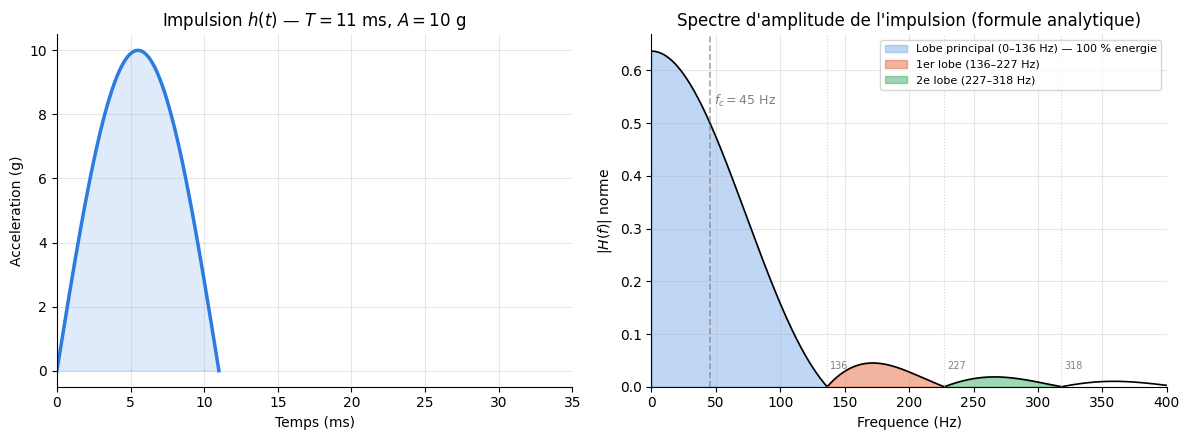

In [53]:
T = T_choc
A = A_choc
f_c = 1 / (2 * T)            # frequence caracteristique ≈ 45.5 Hz
zeros_f = np.array([3, 5, 7]) * f_c   # premiers zeros du spectre

f_arr = np.linspace(0, 400, 80001)    # resolution 0.005 Hz

# Spectre analytique |H(f)| = (2AT/pi) * |cos(pi*f*T)| / |1 - (2fT)^2|
# La singularite en f=fc (numerateur et denominateur nuls) est levee par l'Hopital : limite = AT/2
with np.errstate(divide='ignore', invalid='ignore'):
    num = (2*A*T/np.pi) * np.abs(np.cos(np.pi * f_arr * T))
    den = np.abs(1 - (2 * f_arr * T)**2)
    H   = np.where(den < 1e-8, A*T/2, num/den)

# Energie spectrale (theoreme de Parseval, spectre unilatere)
E_tot  = np.trapezoid(H**2, f_arr)
E_fc   = np.trapezoid(H[f_arr <= f_c    ]**2, f_arr[f_arr <= f_c    ])
E_3fc  = np.trapezoid(H[f_arr <= 3*f_c  ]**2, f_arr[f_arr <= 3*f_c  ])

print(f"f_c = {f_c:.1f} Hz     |   premier zero a {zeros_f[0]:.0f} Hz")
print(f"Energie sous f_c  ({f_c:.0f} Hz)  : {100*E_fc /E_tot:5.1f} %")
print(f"Energie sous 3fc ({zeros_f[0]:.0f} Hz) : {100*E_3fc/E_tot:5.1f} %")

# Normalisation pour le trace : H_n sans unite
H_n  = H / (A * T)     # H(0) = 2/pi ≈ 0.637, H(fc) = 0.5
y_max = np.max(H_n) * 1.05

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Signal temporel ---
t_imp = np.linspace(0, T, 1000)
ax1.plot(t_imp*1e3, A*np.sin(np.pi*t_imp/T)/g_std, color='#2B7BE0', lw=2.5)
ax1.fill_between(t_imp*1e3, A*np.sin(np.pi*t_imp/T)/g_std, alpha=0.15, color='#2B7BE0')
ax1.set_xlabel('Temps (ms)'); ax1.set_ylabel('Acceleration (g)')
ax1.set_title(f'Impulsion $h(t)$ — $T={T*1e3:.0f}$ ms, $A={A/g_std:.0f}$ g')
ax1.set_xlim(0, 35)

# --- Spectre d'amplitude ---
ax2.plot(f_arr, H_n, 'k', lw=1.2)

# Lobes colores
ax2.fill_between(f_arr[f_arr <= zeros_f[0]], H_n[f_arr <= zeros_f[0]],
                 alpha=0.30, color='#2B7BE0',
                 label=f'Lobe principal (0–{zeros_f[0]:.0f} Hz) — {100*E_3fc/E_tot:.0f} % energie')
m1 = (f_arr >= zeros_f[0]) & (f_arr <= zeros_f[1])
ax2.fill_between(f_arr[m1], H_n[m1], alpha=0.45, color='#E05A2B',
                 label=f'1er lobe ({zeros_f[0]:.0f}–{zeros_f[1]:.0f} Hz)')
m2 = (f_arr >= zeros_f[1]) & (f_arr <= zeros_f[2])
ax2.fill_between(f_arr[m2], H_n[m2], alpha=0.45, color='#2BA85A',
                 label=f'2e lobe ({zeros_f[1]:.0f}–{zeros_f[2]:.0f} Hz)')

# Marqueurs
ax2.axvline(f_c, color='gray', ls='--', lw=1.2, alpha=0.7)
ax2.text(f_c+3, y_max*0.80, f'$f_c={f_c:.0f}$ Hz', fontsize=9, color='gray')
for fz in zeros_f:
    ax2.axvline(fz, color='lightgray', ls=':', lw=0.8)
    ax2.text(fz+2, y_max*0.05, f'{fz:.0f}', fontsize=7, color='gray')

ax2.set_xlabel('Frequence (Hz)'); ax2.set_ylabel('$|H(f)|$ norme')
ax2.set_title("Spectre d'amplitude de l'impulsion (formule analytique)")
ax2.set_xlim(0, 400); ax2.set_ylim(0, y_max); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()